# Tiny Dreamer Highway — Colab Sanity Run

**Name:** Esteban  
**Course:** CSC 580 AI 2  
**Assignment:** Final Project — Dream the Road  
**AI tools consulted:** GitHub Copilot

Use this notebook for a short Colab validation run before any longer training job.

## Runtime flow

1. Mount Google Drive.
2. Clone or pull the latest repository snapshot.
3. Install the package.
4. Run a short 3-cycle sanity job.
5. Confirm checkpoints, logs, and analysis artifacts are written.

In [1]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')
REPO_URL = 'https://github.com/estmon8u/CSC_580_Final_Project.git'
DRIVE_ROOT = Path('/content/drive/MyDrive/CSC_580_Final_Project')
ARTIFACT_ROOT = DRIVE_ROOT / 'artifacts'
WORKTREE = Path('/content/CSC_580_Final_Project')

for path in [DRIVE_ROOT, ARTIFACT_ROOT, ARTIFACT_ROOT / 'training_runs']:
    path.mkdir(parents=True, exist_ok=True)

print('Drive root:', DRIVE_ROOT)
print('Artifact root:', ARTIFACT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Drive root: /content/drive/MyDrive/CSC_580_Final_Project
Artifact root: /content/drive/MyDrive/CSC_580_Final_Project/artifacts


In [2]:
%%bash
set -e
REPO_URL='https://github.com/estmon8u/CSC_580_Final_Project.git'
if [ ! -d /content/CSC_580_Final_Project/.git ]; then
  git clone "${REPO_URL}" /content/CSC_580_Final_Project
else
  cd /content/CSC_580_Final_Project
  git pull --ff-only origin main
fi

Updating 18d77cb..9f1f8c2
Fast-forward
 examples/h100_screening_experiment.yaml            |  20 +-
 notebooks/02_colab_sanity_run.ipynb                | 306 ++++++++++-----------
 notebooks/07_colab_screening_run.ipynb             | 126 +++++++--
 src/tiny_dreamer_highway/config.py                 |  17 ++
 .../evaluation/policy_rollout.py                   |  26 +-
 src/tiny_dreamer_highway/models/actor.py           |  54 ++--
 src/tiny_dreamer_highway/models/critic.py          |  21 +-
 src/tiny_dreamer_highway/models/decoder.py         |  18 +-
 src/tiny_dreamer_highway/models/rssm.py            |  34 ++-
 src/tiny_dreamer_highway/models/world_model.py     |  22 +-
 .../training/behavior_learning.py                  |   5 +-
 src/tiny_dreamer_highway/training/experiment.py    |  26 +-
 src/tiny_dreamer_highway/training/pipeline.py      |  34 ++-
 src/tiny_dreamer_highway/utils/__init__.py         |   3 +-
 src/tiny_dreamer_highway/utils/weight_init.py      |  23 ++
 tests/test_beha

From https://github.com/estmon8u/CSC_580_Final_Project
 * branch            main       -> FETCH_HEAD
   18d77cb..9f1f8c2  main       -> origin/main


In [3]:
%%bash
set -e
cd /content/CSC_580_Final_Project
python -m pip install --upgrade pip --quiet
python -m pip install -e . --quiet

In [4]:
import json
import sys
from pathlib import Path

PROJECT_ROOT = Path('/content/CSC_580_Final_Project')
if str(PROJECT_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from tiny_dreamer_highway.config import load_experiment_config
from tiny_dreamer_highway.training import run_training_experiment

CONFIG_PATH = PROJECT_ROOT / 'examples' / 'training_run.yaml'
config = load_experiment_config(CONFIG_PATH)
print('Loaded config from:', CONFIG_PATH)
print('Base cycles:', config.training.cycles)
print('Base batch size:', config.training.batch_size)

Loaded config from: /content/CSC_580_Final_Project/examples/training_run.yaml
Base cycles: 500
Base batch size: 32


In [5]:
RUN_NAME = 'sanity_check_001'
RUN_ARTIFACT_ROOT = ARTIFACT_ROOT / 'training_runs' / RUN_NAME
RUN_ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

CYCLES = 25
WARM_START_STEPS = 64
POLICY_STEPS = 8
CHECKPOINT_INTERVAL = 1
RESUME_FROM = None

print('Run name:', RUN_NAME)
print('Cycles:', CYCLES)
print('Warm-start steps:', WARM_START_STEPS)
print('Policy steps:', POLICY_STEPS)

Run name: sanity_check_001
Cycles: 25
Warm-start steps: 64
Policy steps: 8


In [6]:
print('Launching sanity run. Per-cycle progress lines will appear below.')

training_summary = run_training_experiment(
    config,
    RUN_ARTIFACT_ROOT,
    cycles=CYCLES,
    warm_start_steps=WARM_START_STEPS,
    policy_steps=POLICY_STEPS,
    checkpoint_interval=CHECKPOINT_INTERVAL,
    resume_from=RESUME_FROM,
)

print('Completed cycles:', training_summary.completed_cycles)
print('Latest checkpoint:', training_summary.latest_checkpoint)
print('Latest metrics:', training_summary.latest_record)

Launching sanity run. Per-cycle progress lines will appear below.
[train] starting run | cycles=25 | start_step=1 | warm_start_steps=64 | policy_steps=8 | device=cuda
[train] step=1/25 | warm=64 | policy=8 | replay=72 | world_total=330.3473 | actor=0.9810 | critic=12.0139 | cycle_s=43.2 | elapsed_s=43.2 | checkpoint=checkpoint_00001.pt
[train] step=2/25 | warm=0 | policy=8 | replay=80 | world_total=310.5551 | actor=1.4079 | critic=12.4306 | cycle_s=5.0 | elapsed_s=48.2 | checkpoint=checkpoint_00002.pt
[train] step=3/25 | warm=0 | policy=8 | replay=88 | world_total=110.8618 | actor=1.8810 | critic=15.6752 | cycle_s=6.8 | elapsed_s=55.0 | checkpoint=checkpoint_00003.pt
[train] step=4/25 | warm=0 | policy=8 | replay=96 | world_total=48.3271 | actor=3.4524 | critic=24.0905 | cycle_s=5.0 | elapsed_s=60.0 | checkpoint=checkpoint_00004.pt
[train] step=5/25 | warm=0 | policy=8 | replay=104 | world_total=27.0578 | actor=5.2305 | critic=43.6484 | cycle_s=5.2 | elapsed_s=65.2 | checkpoint=checkpo

In [7]:
summary_path = training_summary.log_dir / 'latest_summary.json'
metrics_csv_path = training_summary.log_dir / 'cycle_metrics.csv'
metrics_jsonl_path = training_summary.log_dir / 'cycle_metrics.jsonl'
summary_payload = json.loads(summary_path.read_text(encoding='utf-8'))

print('Summary exists:', summary_path.exists())
print('CSV exists:', metrics_csv_path.exists())
print('JSONL exists:', metrics_jsonl_path.exists())
print('Checkpoint exists:', training_summary.latest_checkpoint is not None and training_summary.latest_checkpoint.exists())
summary_payload

Summary exists: True
CSV exists: True
JSONL exists: True
Checkpoint exists: True


{'checkpoint_file': '/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/checkpoints/checkpoint_00025.pt',
 'latest_metrics': {'behavior/actor_loss': 19.692726135253906,
  'behavior/critic_loss': 145.2888412475586,
  'behavior/imagined_reward_mean': -1.7484480738639832,
  'behavior/imagined_value_mean': -9.111462116241455,
  'policy_added': 8,
  'replay_size': 264,
  'step': 25,
  'warm_start_added': 0,
  'world_model/kl_loss': 3.046995759010315,
  'world_model/kl_loss_raw': 2.9295549392700195,
  'world_model/reconstruction_loss': 0.04168959707021713,
  'world_model/reward_loss': 3.262780785560608,
  'world_model/total_loss': 6.351466178894043},
 'latest_step': 25}

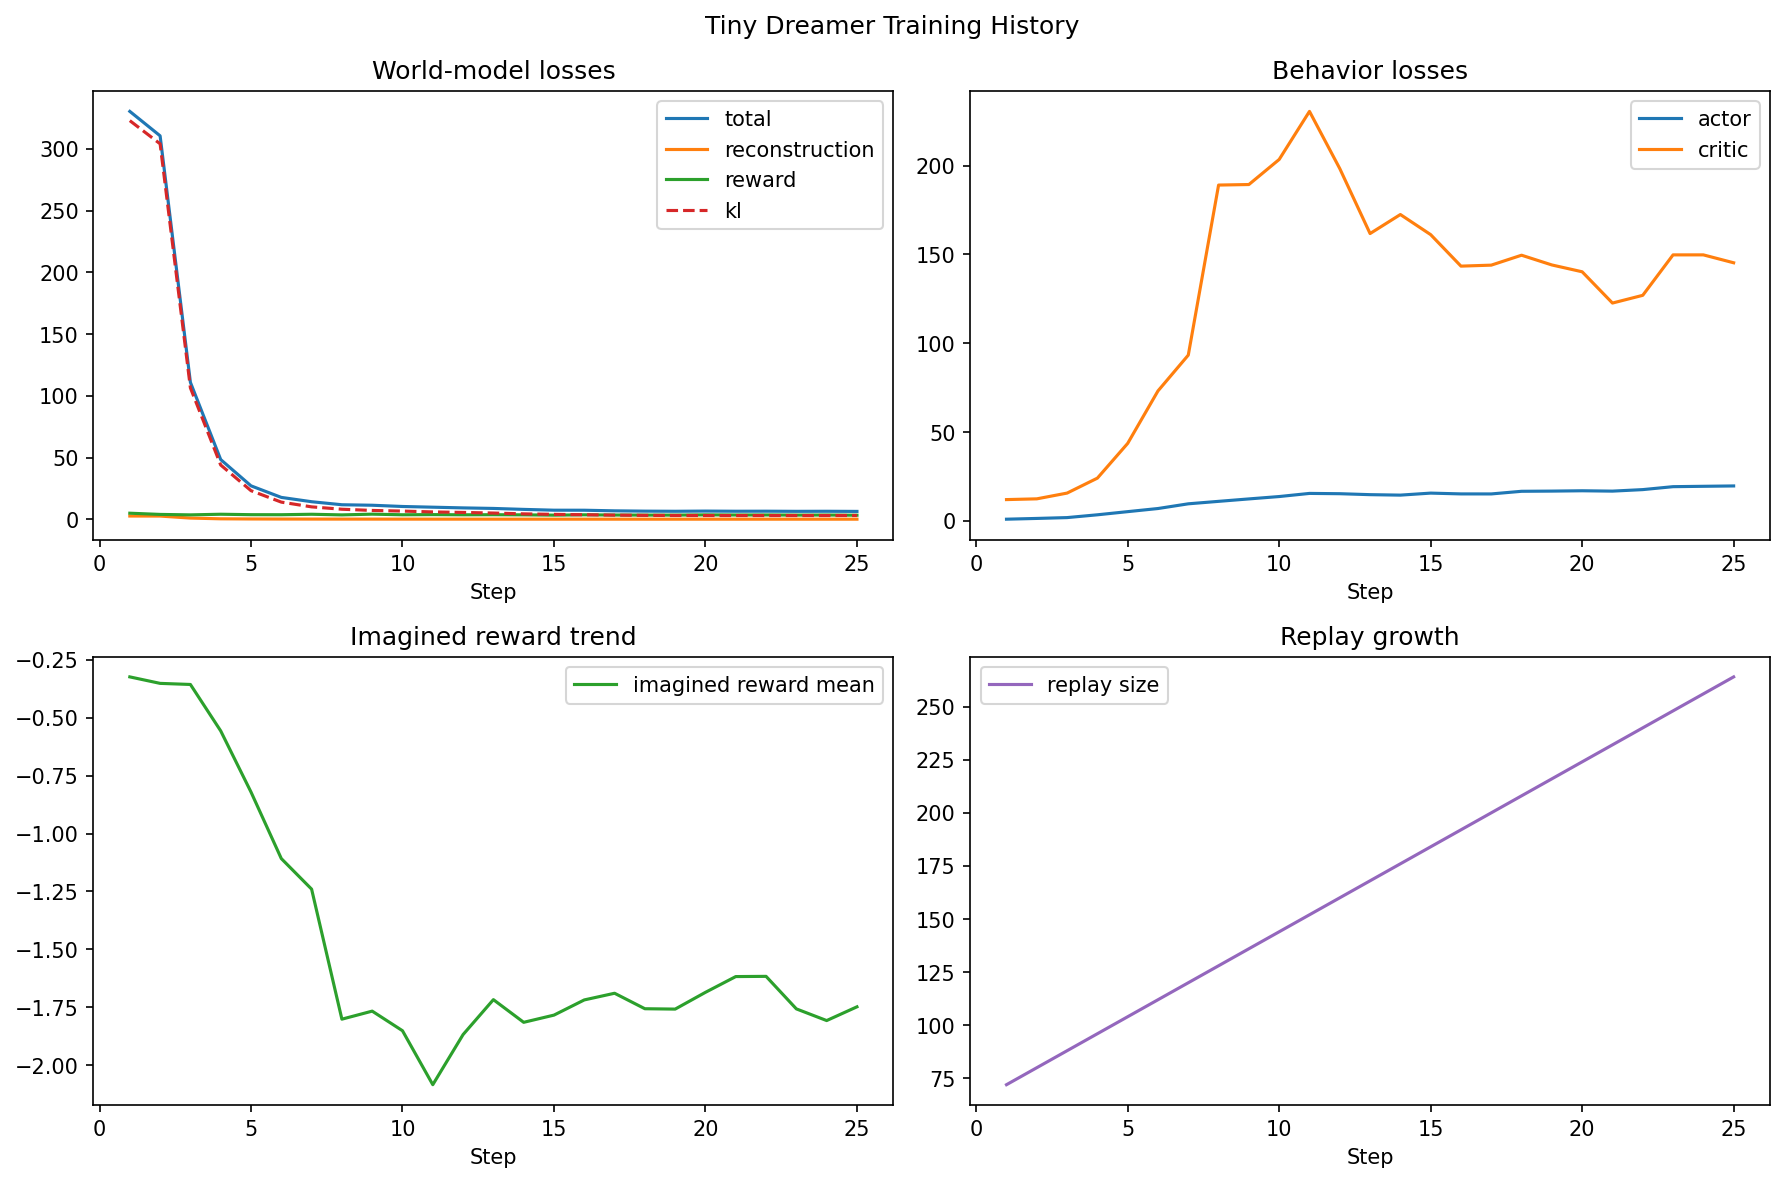

{'summary': PosixPath('/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/analysis/sanity_check_001_summary.json'),
 'curves': PosixPath('/content/drive/MyDrive/CSC_580_Final_Project/artifacts/training_runs/sanity_check_001/analysis/sanity_check_001_curves.png')}

In [8]:
from IPython.display import Image, display
from tiny_dreamer_highway.evaluation import export_training_history_artifacts

analysis_outputs = export_training_history_artifacts(
    training_summary.log_dir / 'cycle_metrics.csv',
    RUN_ARTIFACT_ROOT / 'analysis',
    prefix=RUN_NAME,
)

display(Image(filename=str(analysis_outputs['curves'])))
analysis_outputs

## Agent Driving Demo

Record a short GIF showing the trained policy driving in the real highway-env. The checkpoint from the run above is used to load the actor and world model, then the agent is rolled out for a few episodes.

Using demo recorder from: tiny_dreamer_highway.evaluation.policy_rollout
[demo] episode 1/10 | steps=4 | reward=-0.74 | CRASH | saved sanity_check_001_ep01.gif
[demo] episode 2/10 | steps=3 | reward=-1.48 | CRASH | saved sanity_check_001_ep02.gif
[demo] episode 3/10 | steps=2 | reward=-2.34 | CRASH | saved sanity_check_001_ep03.gif
[demo] episode 4/10 | steps=3 | reward=-1.32 | CRASH | saved sanity_check_001_ep04.gif
[demo] episode 5/10 | steps=3 | reward=-1.41 | CRASH | saved sanity_check_001_ep05.gif
[demo] episode 6/10 | steps=2 | reward=-2.24 | CRASH | saved sanity_check_001_ep06.gif
[demo] episode 7/10 | steps=1 | reward=-3.01 | CRASH | saved sanity_check_001_ep07.gif
[demo] episode 8/10 | steps=1 | reward=-3.01 | CRASH | saved sanity_check_001_ep08.gif
[demo] episode 9/10 | steps=1 | reward=-3.01 | CRASH | saved sanity_check_001_ep09.gif
[demo] episode 10/10 | steps=2 | reward=-2.17 | CRASH | saved sanity_check_001_ep10.gif
[demo] done | avg_reward=-2.07 | summary=sanity_check_00

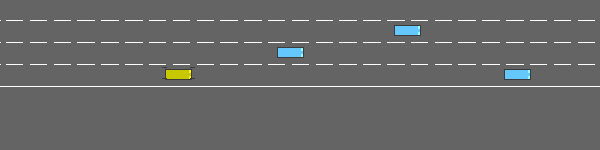


sanity_check_001_ep02.gif


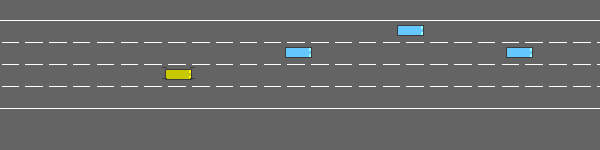


sanity_check_001_ep03.gif


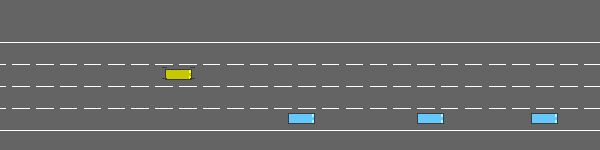


sanity_check_001_ep04.gif


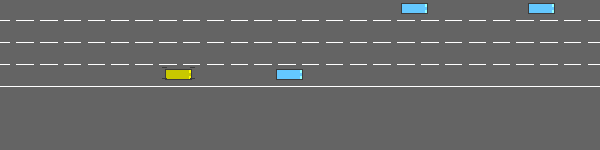


sanity_check_001_ep05.gif


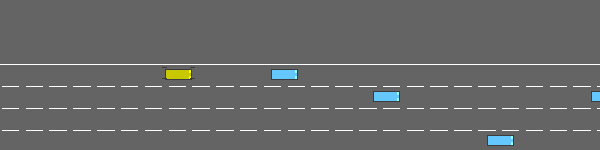


sanity_check_001_ep06.gif


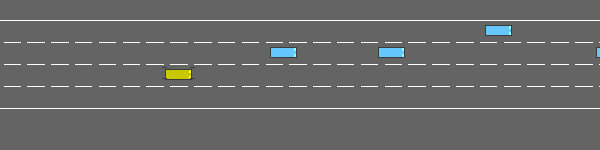


sanity_check_001_ep07.gif


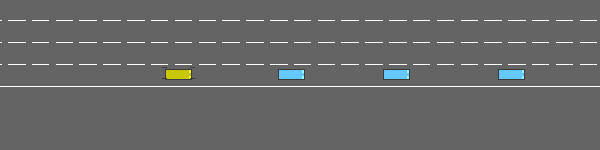


sanity_check_001_ep08.gif


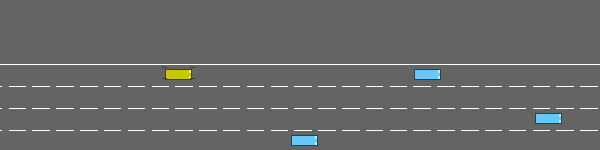


sanity_check_001_ep09.gif


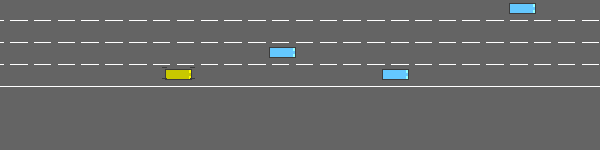


sanity_check_001_ep10.gif


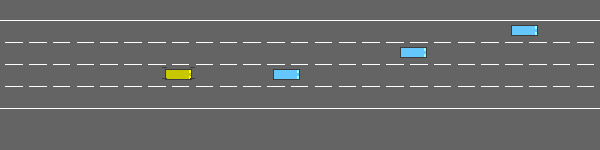

In [9]:
from IPython.display import Image, display
import importlib
import tiny_dreamer_highway.evaluation as evaluation_pkg

try:
    evaluation_pkg = importlib.reload(evaluation_pkg)
    record_demo_videos = evaluation_pkg.record_demo_videos
except (AttributeError, ImportError):
    from tiny_dreamer_highway.evaluation.policy_rollout import record_demo_videos

print('Using demo recorder from:', record_demo_videos.__module__)

demo_outputs = record_demo_videos(
    config,
    checkpoint_path=training_summary.latest_checkpoint,
    output_dir=RUN_ARTIFACT_ROOT / 'demo_videos',
    num_episodes=10,
    max_steps=100,
    fps=15,
    seed=config.seed,
    prefix=RUN_NAME,
    device=config.device,
)

for gif_path in demo_outputs.video_paths:
    print(f'\n{gif_path.name}')
    display(Image(filename=str(gif_path)))